# Adding Decaying Dark Matter to `class_gomp`

This notebook presents a complete **DM decay + Gomp reionization** example. The calculation has two stages:

1. Use `DarkHistory` to generate the ionization and thermal history for the selected dark matter model.
2. Use `class_gomp` to read that history and calculate the CMB angular power spectra.

> Important: `DH_DM_decay_mass` is specified in **GeV** in the `CLASS` parameter dictionary, whereas `mDM` is passed to `DarkHistory` in **eV**. `DH_DM_decay_lifetime_exponent` is $\log_{10}(\tau/\mathrm{s})$.

## 1. Environment and paths

Import the required packages and verify that `darkhistory`, the compiled `class_gomp`, and `DH_DATA_DIR` are available.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

dh_data_dir = os.environ.get("DH_DATA_DIR")
if dh_data_dir is None:
    raise EnvironmentError(
        "Set DH_DATA_DIR and then restart the Jupyter kernel. For example, before starting Jupyter run "
        "`export DH_DATA_DIR=/path/to/darkhistory/data`."
    )

DH_BASE_DIR = Path(dh_data_dir).expanduser().resolve().parent
if str(DH_BASE_DIR) not in sys.path:
    sys.path.append(str(DH_BASE_DIR))

try:
    from classy import Class
    import darkhistory.main as dh_main
    import darkhistory.physics as phys
    from darkhistory.config import load_data
except ImportError as exc:
    raise ImportError(
        "Could not import classy and DarkHistory. Switch to a kernel containing "
        "the compiled class_gomp wrapper and DarkHistory installation."
    ) from exc

print(f"Working directory  : {Path.cwd()}")
print(f"DH_DATA_DIR       : {dh_data_dir}")

Working directory  : /share06/users/w/wangyn/class_gomp/notebooks
DH_DATA_DIR       : /share06/users/w/wangyn/DarkHistory/data


## 2. Model parameters

Two posterior-mean parameter sets are used. 

The **Gomp $+\sum m_\nu+$ DM decay** model, with $m_\chi=1\,\mathrm{GeV}$, has $n_s=0.9743$, $H_0=68.62\,\mathrm{km\,s^{-1}\,Mpc^{-1}}$, $\Omega_b=0.04795$, $\omega_{\rm cdm}=0.11758$, $A_s=2.156\times10^{-9}$, $\sum m_\nu=0$, $\alpha_{\rm gomp}=-2.024$, and $\beta_{\rm gomp}=5.82$. Its decay rate is $\Gamma=0.64\times10^{-25}\,\mathrm{s}^{-1}$.

The **Gomp $+\sum m_\nu$** baseline uses $n_s=0.9738$, $H_0=68.61\,\mathrm{km\,s^{-1}\,Mpc^{-1}}$, $\Omega_b=0.04793$, $\omega_{\rm cdm}=0.11769$, $A_s=2.132\times10^{-9}$, $\sum m_\nu=0$, $\alpha_{\rm gomp}=-2.029$, and $\beta_{\rm gomp}=4.70$.

In [2]:
# Posterior means for Gomp + sum(mnu) + DM decay.

Gamma = 0.64e-25  # s^-1, posterior mean
lifetime = 1.0 / Gamma

cfg = {
    # Primordial spectrum
    "n_s": 0.9743,
    "A_s": 2.156e-9,

    # Background cosmology
    "H0": 68.62,  # km/s/Mpc
    "omega_b": 0.04795 * (68.62 / 100.0) ** 2,
    "omega_cdm": 0.11758,
    "mnu": 0.0,  # eV; CLASS uses 1e-5 eV for numerical stability

    # Decaying dark matter
    "mDM": 1.0e9,  # eV (1 GeV), as expected by DarkHistory
    "lifetime_exponent": np.log10(lifetime),
    "inj_particle": "decay_e",

    # Gomp reionization
    "alpha_gomp": -2.024,  # ln(a_pivot)
    "beta_gomp": 5.82,     # tilt
}

# -----------------------------------------------------------------------------

# Posterior means for Gomp + sum(mnu).

gomp_cfg = {
    # Primordial spectrum
    "n_s": 0.9738,
    "A_s": 2.132e-9,

    # Background cosmology
    "H0": 68.61,  # km/s/Mpc
    "omega_b": 0.04793 * (68.61 / 100.0) ** 2,
    "omega_cdm": 0.11769,
    "mnu": 0.0,  # eV; CLASS uses 1e-5 eV for numerical stability

    # Gomp reionization
    "alpha_gomp": -2.029,  # ln(a_pivot)
    "beta_gomp": 4.70,     # tilt
}


print("\nGomp + sum(mnu) + DM decay configuration (m_chi = 1 GeV):")
for key, value in cfg.items():
    print(f"  {key:20s} = {value}")

print("\nGomp + sum(mnu) configuration:")
for key, value in gomp_cfg.items():
    print(f"  {key:20s} = {value}")


Gomp + sum(mnu) + DM decay configuration (m_chi = 1 GeV):
  n_s                  = 0.9743
  A_s                  = 2.156e-09
  H0                   = 68.62
  omega_b              = 0.022578237598
  omega_cdm            = 0.11758
  mnu                  = 0.0
  mDM                  = 1000000000.0
  lifetime_exponent    = 25.193820026016112
  inj_particle         = decay_e
  alpha_gomp           = -2.024
  beta_gomp            = 5.82

Gomp + sum(mnu) configuration:
  n_s                  = 0.9738
  A_s                  = 2.132e-09
  H0                   = 68.61
  omega_b              = 0.022562242755300003
  omega_cdm            = 0.11769
  mnu                  = 0.0
  alpha_gomp           = -2.029
  beta_gomp            = 4.7


## 3. Generate or reuse the `DarkHistory` cache

The cache filename must match the lookup convention implemented in `class_gomp`. The two steps below first locate and validate the expected cache, then run `DarkHistory` only when a valid table is unavailable.

The cache path is not passed explicitly in the `CLASS` parameter dictionary. Instead, `class_gomp` reconstructs the filename from the model parameters and reads the corresponding file.

### 3.1 Locate and validate the cache

Construct the exact filename expected by `class_gomp`. With `coarsen_factor=30`, a valid table contains four header lines followed by 220 redshift rows and no `NaN` values. An invalid cache is deleted so that it can be regenerated.

In [3]:
h_dm = float(cfg["H0"]) / 100.0
Omega_b_dm = float(cfg["omega_b"]) / h_dm**2
Omega_cdm_dm = float(cfg["omega_cdm"]) / h_dm**2
mnu_dm = max(float(cfg["mnu"]), 1e-5)
mass_gev = float(cfg["mDM"]) / 1e9
lifetime_exponent_string = f"{float(cfg['lifetime_exponent']):.6f}"

cache_name = (
    f"{mass_gev:.6f}_{lifetime_exponent_string}_{float(cfg['H0']):.6f}_"
    f"{Omega_cdm_dm:.6f}_{Omega_b_dm:.6f}_"
    f"{mnu_dm:.6f}_{float(cfg['beta_gomp']):.6f}_"
    f"{float(cfg['alpha_gomp']):.6f}.txt"
)
dh_cache = DH_BASE_DIR / cfg.get("inj_particle", "decay_e") / cache_name

cache_lines = dh_cache.read_text().splitlines() if dh_cache.is_file() else []
# coarsen_factor=30 produces 220 redshift rows, preceded by four header lines.
cache_valid = (
    len(cache_lines) == 224
    and not any("nan" in line.lower() for line in cache_lines)
)

if cache_valid:
    print(f"Valid DarkHistory cache found: {dh_cache}")
elif dh_cache.exists():
    dh_cache.unlink()
    print(f"Invalid cache deleted: {dh_cache}")
else:
    print(f"No DarkHistory cache found: {dh_cache}")

No DarkHistory cache found: /share06/users/w/wangyn/DarkHistory/decay_e/1.000000_25.193820_68.620000_0.249708_0.047950_0.000010_5.820000_-2.024000.txt


### 3.2 Run `DarkHistory` if needed

If the previous cell found no valid cache, set the cosmology, load the `DarkHistory` transfer functions, and evolve the combined DM-decay + Gomp history.

In [4]:
darkhistory_result = None

if cache_valid:
    print("DarkHistory run skipped; using the existing cache.")
else:
    dh_cache.parent.mkdir(parents=True, exist_ok=True)
    phys.set_cosmology_params({
        "H0": float(cfg["H0"]),
        "Omega_b": Omega_b_dm,
        "Omega_cdm": Omega_cdm_dm,
        "mnu": mnu_dm,
    })

    binning = load_data("binning")
    dep_tf_data = load_data("dep_tf")
    ics_tf_data = load_data("ics_tf")

    darkhistory_result = dh_main.evolve(
        mDM=float(cfg["mDM"]),
        DM_process="decay",
        lifetime=10 ** float(cfg["lifetime_exponent"]),
        primary=cfg.get("inj_particle", "decay_e"),
        start_rs=3000,
        end_rs=4,
        coarsen_factor=30,
        backreaction=True,
        reion_switch=True,
        reion_rs=800,
        lna_pivot=float(cfg["alpha_gomp"]),
        tilt=float(cfg["beta_gomp"]),
        binning=binning,
        dep_tf_data=dep_tf_data,
        ics_tf_data=ics_tf_data,
    )

    print(f"DarkHistory cache created: {dh_cache}")

[2026-07-30 18:44:12,678] INFO: darkhistory.config: Loaded deposition transfer functions.
[2026-07-30 18:44:33,799] INFO: darkhistory.config: Loaded ICS transfer functions.
100%|██████████| 221/221 [01:20<00:00,  2.75it/s]

DarkHistory cache created: /share06/users/w/wangyn/DarkHistory/decay_e/1.000000_25.193820_68.620000_0.249708_0.047950_0.000010_5.820000_-2.024000.txt


## 4. Configure `class_gomp`

The essential parameters for adding decaying dark matter are:

- `DH_DM_decay_flag = 1`
- `DH_DM_decay_mass`: dark matter mass in GeV
- `DH_DM_decay_lifetime_exponent`: $\log_{10}(\tau/\mathrm{s})$

The Gomp model is controlled by `reio_parametrization = reio_gomp_noSR`, `alpha_gomp`, and `beta_gomp`. 

The `CLASS` physics and precision configuration below follows the baseline settings reported in Figure 48 of [*The Atacama Cosmology Telescope: DR6 Constraints on Extended Cosmological Models*](https://arxiv.org/pdf/2503.14454), with $\ell_{\max}=9500$.

In [5]:
# ACT DR6 baseline CLASS physics and precision settings.
act_precision = {
    "T_cmb": 2.7255,
    "YHe": "BBN",
    "non_linear": "hmcode",
    "hmcode_version": "2020",
    "recombination": "HyRec",
    "modes": "s",
    "l_max_scalars": 9500,
    "delta_l_max": 1800,
    "P_k_max_h/Mpc": 100.0,
    "l_logstep": 1.025,
    "l_linstep": 20,
    "perturbations_sampling_stepsize": 0.05,
    "l_switch_limber": 30.0,
    "hyper_sampling_flat": 32.0,
    "l_max_g": 40,
    "l_max_ur": 35,
    "l_max_pol_g": 60,
    "ur_fluid_approximation": 2,
    "ur_fluid_trigger_tau_over_tau_k": 130.0,
    "radiation_streaming_approximation": 2,
    "radiation_streaming_trigger_tau_over_tau_k": 240.0,
    "hyper_flat_approximation_nu": 7000.0,
    "transfer_neglect_delta_k_S_t0": 0.17,
    "transfer_neglect_delta_k_S_t1": 0.05,
    "transfer_neglect_delta_k_S_t2": 0.17,
    "transfer_neglect_delta_k_S_e": 0.17,
    "accurate_lensing": 1,
    "start_small_k_at_tau_c_over_tau_h": 0.0004,
    "start_large_k_at_tau_h_over_tau_k": 0.05,
    "tight_coupling_trigger_tau_c_over_tau_h": 0.005,
    "tight_coupling_trigger_tau_c_over_tau_k": 0.008,
    "start_sources_at_tau_c_over_tau_h": 0.006,
    "l_max_ncdm": 30,
    "tol_ncdm_synchronous": 1.0e-6,
}


def build_class_params(config, include_dm_decay=False):
    """Build matching class_gomp dictionaries for the two models."""
    params = {
        "output": "tCl,pCl,lCl,mPk",
        "lensing": "yes",
        "n_s": float(config["n_s"]),
        "A_s": float(config["A_s"]),
        "h": float(config["H0"]) / 100.0,
        "omega_b": float(config["omega_b"]),
        "omega_cdm": float(config["omega_cdm"]),
        "N_ur": 2.0308,
        "T_ncdm": 0.71611,
        "N_ncdm": 1,
        "m_ncdm": max(float(config["mnu"]), 1e-5),
        "reio_parametrization": "reio_gomp_noSR",
        "z_reio": 800,
        "beta_gomp": float(config["beta_gomp"]),
        "alpha_gomp": float(config["alpha_gomp"]),
        **act_precision,
    }

    if include_dm_decay:
        params.update({
            "DH_DM_decay_flag": 1,
            "DH_DM_decay_mass": float(config["mDM"]) / 1e9,
            "DH_DM_decay_lifetime_exponent": float(config["lifetime_exponent"]),
        })

    return params


class_params_gomp = build_class_params(gomp_cfg, include_dm_decay=False)
class_params_dm = build_class_params(cfg, include_dm_decay=True)

print("Gomp + sum(mnu):")
print(f"  alpha_gomp = {class_params_gomp['alpha_gomp']}")
print(f"  beta_gomp  = {class_params_gomp['beta_gomp']}")
print("Gomp + sum(mnu) + DM decay (m_chi = 1 GeV):")
for key in ["alpha_gomp", "beta_gomp", "DH_DM_decay_mass", "DH_DM_decay_lifetime_exponent"]:
    print(f"  {key:32s} = {class_params_dm[key]}")

Gomp + sum(mnu):
  alpha_gomp = -2.029
  beta_gomp  = 4.7
Gomp + sum(mnu) + DM decay (m_chi = 1 GeV):
  alpha_gomp                       = -2.024
  beta_gomp                        = 5.82
  DH_DM_decay_mass                 = 1.0
  DH_DM_decay_lifetime_exponent    = 25.193820026016112


## 5. Run `CLASS`

The high-accuracy settings and $\ell_{\max}=9500$ make this cell relatively expensive because `CLASS` is run twice: once for Gomp $+\sum m_\nu$ and once for Gomp $+\sum m_\nu+$ DM decay.

In [6]:
def run_class(parameters, label):
    cosmo = Class()
    print(f"Running CLASS: {label}\n", flush=True)
    try:
        cosmo.set(parameters)
        cosmo.compute()
    except Exception:
        try:
            cosmo.struct_cleanup()
            cosmo.empty()
        except Exception:
            pass
        raise
    print(f"CLASS calculation finished: {label}\n", flush=True)
    return cosmo


cosmo_gomp = run_class(class_params_gomp, "Gomp + sum(mnu)")
cosmo_dm = run_class(class_params_dm, "Gomp + sum(mnu) + DM decay, m_chi = 1 GeV")

Running CLASS: Gomp + sum(mnu)

reionization start = 7.396500e+01 
CLASS calculation finished: Gomp + sum(mnu)

Running CLASS: Gomp + sum(mnu) + DM decay, m_chi = 1 GeV

Attempting to open file: /share06/users/w/wangyn/DarkHistory/data/../decay_e/1.000000_25.193820_68.620000_0.249708_0.047950_0.000010_5.820000_-2.024000.txt
CLASS calculation finished: Gomp + sum(mnu) + DM decay, m_chi = 1 GeV

reionization start = 3.072150e+02 


## 6. Derived cosmological parameters

In [7]:
derived_names = [
    "tau_reio",
    "conformal_age",
    "sigma8",
    "theta_s_100",
    "Omega_m",
    "YHe",
    "age",
]
def get_derived(cosmo):
    result = cosmo.get_current_derived_parameters(derived_names)
    result["rs_drag"] = cosmo.rs_drag()
    return result


derived_gomp = get_derived(cosmo_gomp)
derived_dm = get_derived(cosmo_dm)

print(f"{'parameter':16s}  {'Gomp + sum(mnu)':>20s}  {'Gomp + sum(mnu) + DM':>24s}")
for key in derived_gomp:
    print(f"{key:16s}  {derived_gomp[key]:14.8g}  {derived_dm[key]:14.8g}")

parameter              Gomp + sum(mnu)      Gomp + sum(mnu) + DM
tau_reio             0.063891788     0.071432706
conformal_age          14208.799       14212.162
sigma8                0.82390534      0.82795064
theta_s_100            1.0411102       1.0409807
Omega_m               0.29794423      0.29765776
YHe                   0.24535811       0.2453636
age                    13.760582        13.76227
rs_drag                147.51654       147.54153


## 7. CMB angular power spectra

The figure compares Gomp $+\sum m_\nu$ with Gomp $+\sum m_\nu+$ DM decay at $m_\chi=1\,\mathrm{GeV}$. Absolute TT and EE spectra in the upper panels, normalized model shifts and Planck residuals below, and a low-$\ell$ EE inset.

### 7.1 Read the `CLASS` spectra

Convert the dimensionless lensed $C_\ell$ returned by both `CLASS` instances into $D_\ell$. TT, EE, and TE are expressed in $\mu\mathrm{K}^2$.

In [8]:
def cmb_spectrum(cosmo, lmax=9500):
    """Return lensed D_ell spectra in microkelvin squared."""
    cls = cosmo.lensed_cl(lmax)
    ell = np.asarray(cls["ell"], dtype=float)
    factor = ell * (ell + 1.0) / (2.0 * np.pi)
    uK2 = (cosmo.T_cmb() * 1e6) ** 2
    return {
        "ell": ell,
        "TT": factor * cls["tt"] * uK2,
        "EE": factor * cls["ee"] * uK2,
        "TE": factor * cls["te"] * uK2,
        "PP": ell**2 * (ell + 1.0)**2 * cls["pp"] / (2.0 * np.pi),
    }


gomp_spectrum = cmb_spectrum(cosmo_gomp)
dm_spectrum = cmb_spectrum(cosmo_dm)

### 7.2 Download and prepare the Planck PR3 spectra

Compare the CMB temperature and E-mode polarization spectra of the two models, together with their normalized differences and the Planck 2018 residuals.

In [9]:
from io import BytesIO
from urllib.request import urlopen


PLANCK_BASE_URL = (
    "https://irsa.ipac.caltech.edu/data/Planck/release_3/"
    "ancillary-data/cosmoparams/"
)

PLANCK_FILES = {
    "TT_full": "COM_PowerSpect_CMB-TT-full_R3.01.txt",
    "TT_binned": "COM_PowerSpect_CMB-TT-binned_R3.01.txt",
    "EE_full": "COM_PowerSpect_CMB-EE-full_R3.01.txt",
    "EE_binned": "COM_PowerSpect_CMB-EE-binned_R3.02.txt",
}


def load_planck_product(filename):
    """Load one public Planck PR3 text product without writing a file."""
    url = PLANCK_BASE_URL + filename
    with urlopen(url, timeout=60) as response:
        data = np.loadtxt(BytesIO(response.read()), comments="#")
    if data.ndim == 1:
        data = data[None, :]
    # Columns: ell, Dl, -dDl, +dDl, BestFit; the last column is not needed here.
    return {
        "ell": data[:, 0],
        "Dl": data[:, 1],
        "yerr": np.vstack([np.abs(data[:, 2]), np.abs(data[:, 3])]),
    }


def add_planck_bin_edges(full, binned, first_ell=30, width=30):
    """Reconstruct the integer multipole limits of official PR3 bins."""
    # The public binned files provide ell_eff, but not ell_min and ell_max.
    # Their display bins start at ell=30 with width 30; the last bin may be shorter.
    result = dict(binned)
    nbin = len(binned["ell"])
    last_ell = int(np.nanmax(full["ell"]))
    expected = int(np.ceil((last_ell - first_ell + 1) / width))
    if nbin != expected:
        raise ValueError(f"Unexpected number of Planck bins: {nbin} != {expected}")
    result["ell_min"] = first_ell + width * np.arange(nbin, dtype=int)
    result["ell_max"] = np.minimum(result["ell_min"] + width - 1, last_ell)
    return result


def make_hybrid_planck_data(full, binned, split=30):
    """Use unbinned points below ell=30 and official bins above it."""
    low = full["ell"] < split
    nlow = np.count_nonzero(low)
    return {
        "ell": np.concatenate([full["ell"][low], binned["ell"]]),
        "Dl": np.concatenate([full["Dl"][low], binned["Dl"]]),
        "yerr": np.concatenate([full["yerr"][:, low], binned["yerr"]], axis=1),
        "ell_min": np.concatenate([full["ell"][low].astype(int), binned["ell_min"]]),
        "ell_max": np.concatenate([full["ell"][low].astype(int), binned["ell_max"]]),
        "is_binned": np.concatenate([
            np.zeros(nlow, dtype=bool),
            np.ones(len(binned["ell"]), dtype=bool),
        ]),
    }


def bin_theory_Dl(theory_ell, theory_Dl, ell_eff, ell_min, ell_max):
    """Apply the Planck display-bin convention to a theoretical D_ell."""
    result = np.full(len(ell_eff), np.nan)
    for i, (leff, lo, hi) in enumerate(zip(ell_eff, ell_min, ell_max)):
        integer_ell = np.arange(lo, hi + 1, dtype=float)
        if lo < theory_ell.min() or hi > theory_ell.max():
            continue
        # Evaluate the theory at every integer multipole in this Planck bin.
        values = np.interp(integer_ell, theory_ell, theory_Dl)
        # Planck weights C_ell by ell(ell+1). In D_ell units this gives
        # D_b = ell_eff(ell_eff+1) sum(D_ell) / sum[ell(ell+1)].
        denominator = np.sum(integer_ell * (integer_ell + 1.0))
        result[i] = leff * (leff + 1.0) * np.sum(values) / denominator
    return result


def theory_on_planck_grid(data, theory_ell, theory_Dl):
    """Match a theoretical D_ell to the hybrid Planck data vector."""
    result = np.full(len(data["ell"]), np.nan)
    unbinned = ~data["is_binned"]
    binned = data["is_binned"]
    # Low-ell points are evaluated individually; high-ell points are bandpowers.
    result[unbinned] = np.interp(data["ell"][unbinned], theory_ell, theory_Dl)
    result[binned] = bin_theory_Dl(
        theory_ell,
        theory_Dl,
        data["ell"][binned],
        data["ell_min"][binned],
        data["ell_max"][binned],
    )
    return result


raw_planck = {key: load_planck_product(name) for key, name in PLANCK_FILES.items()}
planck_data = {}
for spectrum in ["TT", "EE"]:
    full = raw_planck[f"{spectrum}_full"]
    binned = add_planck_bin_edges(full, raw_planck[f"{spectrum}_binned"])
    planck_data[spectrum] = make_hybrid_planck_data(full, binned)

print("Planck PR3 TT and EE products loaded and prepared in memory.")

Planck PR3 TT and EE products loaded and prepared in memory.


### 7.3 Plot the TT and EE comparison

Compare the CMB temperature and E-mode polarization spectra of the two models, together with their normalized differences and the Planck 2018 residuals.

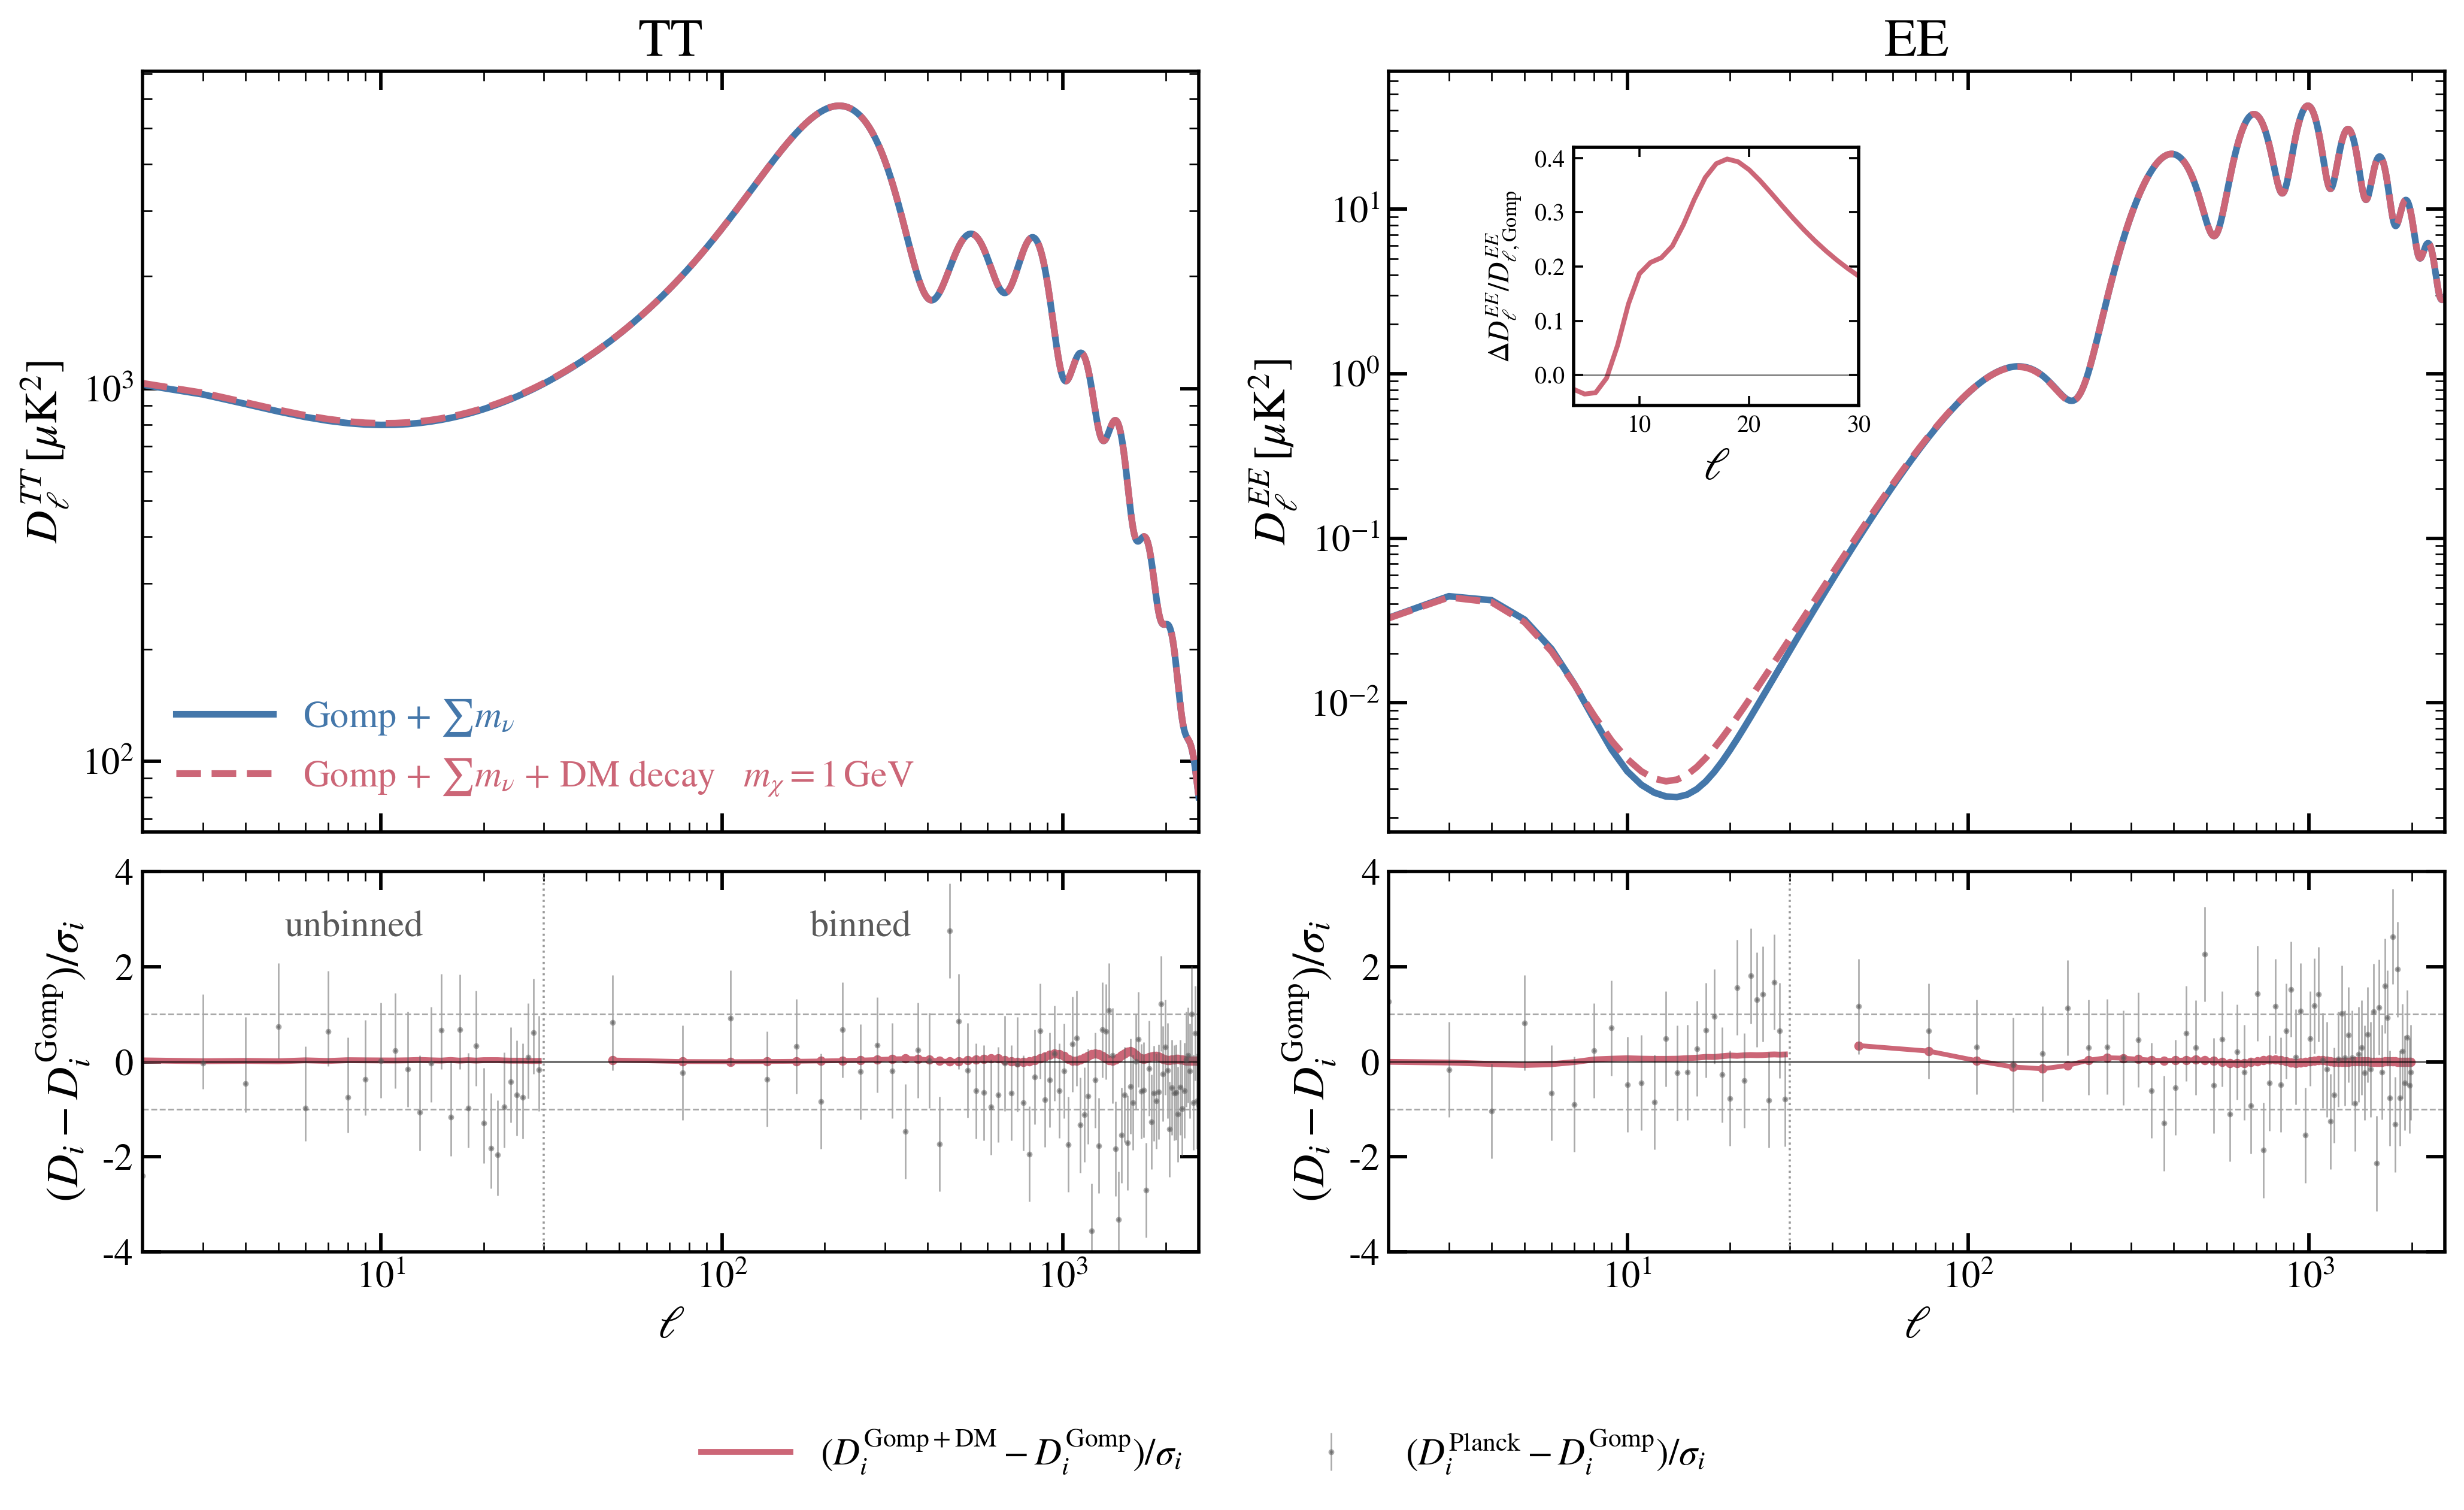

In [10]:
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("retina")
except ImportError:
    pass

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "figure.dpi": 160,
    "font.size": 14,
    "axes.labelsize": 17,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "axes.linewidth": 1.25,
    "axes.unicode_minus": False,
})

color_gomp = "#4477AA"
color_dm = "#CC6677"
color_data = "0.35"
lmin, lmax = 2, 2500

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13.5, 8.0),
    sharex="col",
    gridspec_kw={"height_ratios": [2.0, 1.0], "hspace": 0.07, "wspace": 0.18},
)

for column, spectrum in enumerate(["TT", "EE"]):
    ax = axes[0, column]
    rax = axes[1, column]
    x = gomp_spectrum["ell"]
    y_gomp = gomp_spectrum[spectrum]
    y_dm = np.interp(x, dm_spectrum["ell"], dm_spectrum[spectrum])
    theory_mask = (
        (x >= lmin) & (x <= lmax) & (y_gomp > 0) & (y_dm > 0)
        & np.isfinite(y_gomp) & np.isfinite(y_dm)
    )

    ax.plot(
        x[theory_mask], y_gomp[theory_mask],
        color=color_gomp, lw=2.5, label=r"Gomp + $\sum m_\nu$",
    )
    ax.plot(
        x[theory_mask], y_dm[theory_mask],
        color=color_dm, lw=2.5, ls="--",
        label=r"Gomp + $\sum m_\nu$ + DM decay   $m_\chi=1\,{\rm GeV}$",
    )
    ax.set(xscale="log", yscale="log", xlim=(lmin, lmax), title=spectrum)
    ax.set_ylabel(rf"$D_\ell^{{{spectrum}}}\,[\mu{{\rm K}}^2]$")

    data = planck_data[spectrum]
    gomp_at_data = theory_on_planck_grid(data, x, y_gomp)
    dm_at_data = theory_on_planck_grid(data, x, y_dm)
    sigma = 0.5 * (data["yerr"][0] + data["yerr"][1])
    good = (
        (data["ell"] >= lmin) & (data["ell"] <= lmax)
        & np.isfinite(gomp_at_data) & np.isfinite(dm_at_data)
        & np.isfinite(sigma) & (sigma > 0)
    )
    ell_data = data["ell"][good]
    is_binned = data["is_binned"][good]
    data_pull = (data["Dl"][good] - gomp_at_data[good]) / sigma[good]
    model_pull = (dm_at_data[good] - gomp_at_data[good]) / sigma[good]
    normalized_yerr = data["yerr"][:, good] / sigma[good][None, :]

    for segment, (selection, marker, width) in enumerate([
        (~is_binned, None, 2.2),
        (is_binned, "o", 1.8),
    ]):
        rax.plot(
            ell_data[selection], model_pull[selection],
            color=color_dm, lw=width, marker=marker, ms=2.5,
            label=(
                r"$(D_i^{\rm Gomp+DM}-D_i^{\rm Gomp})/\sigma_i$"
                if segment == 0 else "_nolegend_"
            ),
        )
    rax.errorbar(
        ell_data, data_pull, yerr=normalized_yerr,
        fmt=".", ms=2.4, elinewidth=0.6, alpha=0.5,
        color=color_data, ecolor=color_data,
        label=r"$(D_i^{\rm Planck}-D_i^{\rm Gomp})/\sigma_i$",
    )
    rax.axhline(0, color="k", lw=0.8, alpha=0.6)
    rax.axhline(1, color="0.65", lw=0.6, ls="--")
    rax.axhline(-1, color="0.65", lw=0.6, ls="--")
    rax.axvline(30, color="0.6", lw=0.8, ls=":")
    rax.set(xscale="log", xlim=(lmin, lmax), ylim=(-4, 4), xlabel=r"$\ell$")
    rax.set_ylabel(r"$(D_i-D_i^{\rm Gomp})/\sigma_i$")

    for panel in [ax, rax]:
        panel.tick_params(which="major", direction="in", top=True, right=True, length=7, width=1.3)
        panel.tick_params(which="minor", direction="in", top=True, right=True, length=3.5)

axes[1, 0].text(0.20, 0.90, "unbinned", transform=axes[1, 0].transAxes, ha="center", va="top", color="0.35")
axes[1, 0].text(0.68, 0.90, "binned", transform=axes[1, 0].transAxes, ha="center", va="top", color="0.35")

# Low-ell EE fractional-change inset.
ee_gomp = gomp_spectrum["EE"]
ee_dm = np.interp(gomp_spectrum["ell"], dm_spectrum["ell"], dm_spectrum["EE"])
ee_fraction = np.full_like(ee_gomp, np.nan)
valid_ee = np.isfinite(ee_gomp) & np.isfinite(ee_dm) & (np.abs(ee_gomp) > 1e-30)
ee_fraction[valid_ee] = (ee_dm[valid_ee] - ee_gomp[valid_ee]) / ee_gomp[valid_ee]
inset_mask = (gomp_spectrum["ell"] >= 4) & (gomp_spectrum["ell"] <= 30)
axins = axes[0, 1].inset_axes([0.175, 0.56, 0.27, 0.34])
axins.plot(gomp_spectrum["ell"][inset_mask], ee_fraction[inset_mask], color=color_dm, lw=1.8)
axins.axhline(0, color="k", lw=0.6, alpha=0.5)
axins.set(xlim=(4, 30), xticks=[10, 20, 30], xlabel=r"$\ell$")
axins.set_ylabel(r"$\Delta D_\ell^{EE}/D_{\ell,{\rm Gomp}}^{EE}$", fontsize=11)
axins.tick_params(direction="in", top=True, right=True, labelsize=9)
axins.set_facecolor("white")

legend = axes[0, 0].legend(frameon=False, loc="lower left", handlelength=2.6)
legend.get_texts()[0].set_color(color_gomp)
legend.get_texts()[1].set_color(color_dm)

handles_lower, labels_lower = axes[1, 0].get_legend_handles_labels()
fig.legend(
    handles_lower[:2],
    [
        r"$(D_i^{\rm Gomp+DM}-D_i^{\rm Gomp})/\sigma_i$",
        r"$(D_i^{\rm Planck}-D_i^{\rm Gomp})/\sigma_i$",
    ],
    loc="lower center", bbox_to_anchor=(0.5, 0.012), ncol=2,
    frameon=False, handlelength=2.4, columnspacing=2.8,
)

fig.subplots_adjust(left=0.09, right=0.98, bottom=0.18, top=0.95)
plt.show()

## 8. Release `CLASS` memory

Run this cell after all required results have been extracted. To access either `CLASS` instance again afterward, rerun the “Run `CLASS`” cell and the relevant downstream cells.

In [11]:
for cosmo in [cosmo_gomp, cosmo_dm]:
    cosmo.struct_cleanup()
    cosmo.empty()
print("CLASS memory released for both models.")

CLASS memory released for both models.
